![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

# Clustering Antarctic Penguin Species (Unsupervised Learning & K-Means, Python, 2025)

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

In [92]:
# Import python librarie
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [93]:
# Load data
penguins_df = pd.read_csv('penguins.csv')

penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [94]:
#EDA - summary info 
penguins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex                332 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.1+ KB


In [95]:
#EDA - null values
penguins_df.isna().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [96]:
#EDA - descriptive statistics
penguins_df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,332.000000,332.000000,332.000000,332.000000
mean,44.021084,17.153012,200.975904,4206.475904
std,5.452462,1.960275,14.035971,806.361278
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.700000,17.300000,197.000000,4025.000000
75%,48.625000,18.700000,213.000000,4781.250000
max,59.600000,21.500000,231.000000,6300.000000


In [97]:
#EDA - value counts
penguins_df['sex'].value_counts()

MALE      167
FEMALE    165
Name: sex, dtype: int64

### Note

Kmeans is a distance-based clustering method, so this difference in magnitude can raise problem.

- As there is a large variation in the magnitude in the data
- for example between culmen_depth_mm and body_mass_g

#### Choose the right number of cluster of the dataset

- using KMeans and inertia graph
- based on the plot the good number of inertia is 3

#### With feature standardisation

- Standardise data
- Bring all variables to the same magnitude - mean will be around zero
- Fit both the scaler and the kmeans then use predict to obtain the cluster labels

#### #Without feature standardisation

- Evaluating the clustering of the penguins
- Use fit_predict() method  to fit model and obtaib cluster labels: labels
- Create a DataFrame with labels and species as column: df

#### #Standardise data

- Bring all variables to the same magnitude
- Initiate StandardScaler
- fit and transform data
- After standardisation the magnitude/scale seems similar.

In [98]:
#Transform sex column to binary values
#sex_MAlE means: 1 = male and 0 = female
penguins_df_dummies = pd.get_dummies(penguins_df, columns = ['sex'], drop_first = True)

penguins_df_dummies.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_MALE
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
3,36.7,19.3,193.0,3450.0,0
4,39.3,20.6,190.0,3650.0,1


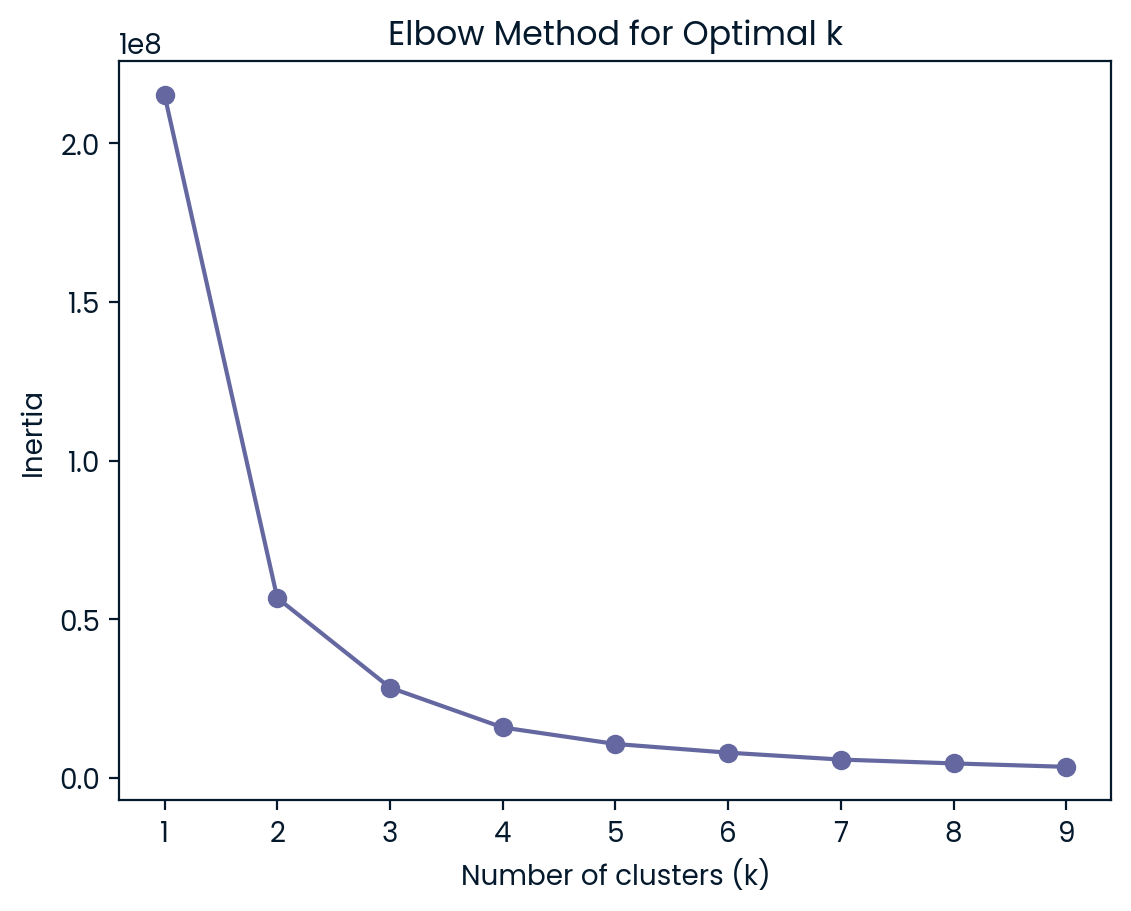

In [99]:
#KMeans and inertia graph

#create copy
features_for_clustering = penguins_df_dummies.copy()

#Create a KMeans instance called model with k clusters
ks = range (1, 10)
inertias = []

for k in ks:
    #Create a KMeans instance with k clusters: model
    model = KMeans(n_clusters = k)

    #Fit model to sampels
    model.fit(penguins_df_dummies)

    #Append the inertia to the list of inertias
    inertias.append(model.inertia_)

#Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(ks)
plt.show()


In [100]:
#With feature standardisation

scaler = StandardScaler()
kmeans = KMeans(n_clusters = 3, n_init = 10, random_state = 42)

pipeline = make_pipeline(scaler, kmeans)
pipeline.fit(penguins_df_dummies)

#Cluster labels with the .predict() method
labels = pipeline.predict(penguins_df_dummies)
penguins_df_dummies['labels'] = labels

numeric_cols = [
    'culmen_length_mm',
    'culmen_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

#Averages of the groups
stat_penguins = (penguins_df_dummies.groupby('labels')[numeric_cols].mean())
stat_penguins

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
labels,,,,
0,43.878302,19.111321,194.764151,4006.603774
1,47.568067,14.996639,217.235294,5092.436975
2,40.217757,17.611215,189.046729,3419.158879


In [101]:
#Without feature standardisation

#Create a KMeans model with 3 clusters: model
model_raw = KMeans(n_clusters = 3, n_init = 10, random_state = 42)

#Cluster label with .fit_predict() method
labels_2 = model_raw.fit_predict(penguins_df_dummies)
penguins_df_dummies['labels_2'] = labels_2

#Averages of the groups
stat_penguins_2 = penguins_df_dummies.groupby('labels_2')[numeric_cols].mean()
stat_penguins_2


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
labels_2,,,,
0,48.935714,15.531429,220.614286,5435.357143
1,41.286335,18.037267,190.086957,3522.049689
2,44.974257,16.867327,204.722772,4445.792079


In [102]:
#Standardise data

#Initiate StandardScaler
scaler = StandardScaler()

#fit and transform data
penguins_df_st = scaler.fit_transform(penguins_df_dummies)

#Descriptive staistics of the standardised data
print(f'Descriptive statistics of standardised data: ')
pd.DataFrame(penguins_df_st).describe()



Descriptive statistics of standardised data: 


,0,1,2,3,4,5,6
count,3.320000e+02,3.320000e+02,3.320000e+02,3.320000e+02,3.320000e+02,3.320000e+02,3.320000e+02
mean,-4.708416e-16,1.284113e-16,7.276642e-16,4.280378e-17,-1.391123e-16,-7.356900e-18,-8.560756e-17
std,1.001509e+00,1.001509e+00,1.001509e+00,1.001509e+00,1.001509e+00,1.001509e+00,1.001509e+00
min,-2.189667e+00,-2.070694e+00,-2.067519e+00,-1.871059e+00,-1.006042e+00,-1.252243e+00,-1.536550e+00
25%,-8.304338e-01,-7.934376e-01,-7.831643e-01,-8.153502e-01,-1.006042e+00,-1.252243e+00,-1.312205e-01
50%,1.247034e-01,7.509650e-02,-2.836929e-01,-2.253950e-01,9.939939e-01,-3.760488e-03,-1.312205e-01
75%,8.456482e-01,7.903599e-01,8.579560e-01,7.138756e-01,9.939939e-01,1.244722e+00,1.274109e+00
max,2.861539e+00,2.220887e+00,2.142311e+00,2.600180e+00,9.939939e-01,1.244722e+00,1.274109e+00
